In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

PALETTE = ['#FCA7DE', '#C94B8C', '#69330A', '#A8631E', '#A9CF88', '#2A4215']
PALETTE_CMAP = LinearSegmentedColormap.from_list('project', PALETTE, N=256)
from pathlib import Path
from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path('../')
DATA_OUT     = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_OUT / 'nhanes_clean.csv')
print(f"Loaded: {df.shape}")
print(df.head())

Loaded: (16501, 7)
      LBXGH    BMXBMI  RIDAGEYR  RIAGENDR  RIDRETH3  cycle_2021  diabetes
0 -0.176761 -0.392119 -0.510449       1.0       6.0         1.0       0.0
1 -0.176761  0.558001  0.789385       1.0       3.0         1.0       0.0
2  0.415871  0.002546 -0.453935       2.0       2.0         1.0       1.0
3 -0.176761 -0.158244 -0.510449       1.0       1.0         1.0       0.0
4 -0.176761 -0.158244  0.732870       2.0       3.0         1.0       0.0


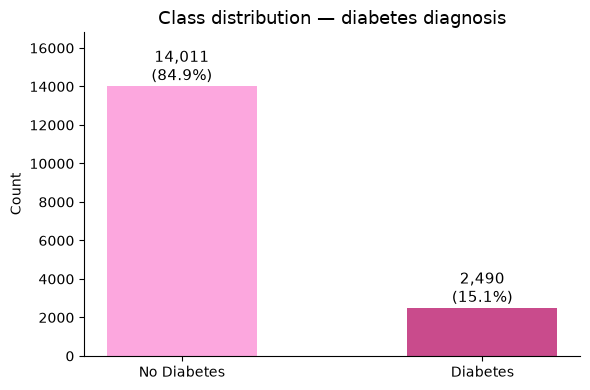

In [3]:
# figure 1: class distribution

fig, ax = plt.subplots(figsize=(6, 4))

counts = df['diabetes'].value_counts().sort_index()
labels = ['No Diabetes', 'Diabetes']
colors = PALETTE[:2]

bars = ax.bar(labels, counts.values, color=colors, width=0.5)

# Add count and percentage labels on bars
total = len(df)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}\n({count/total:.1%})',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Class distribution — diabetes diagnosis', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_class_distribution.png', dpi=150)
plt.show()


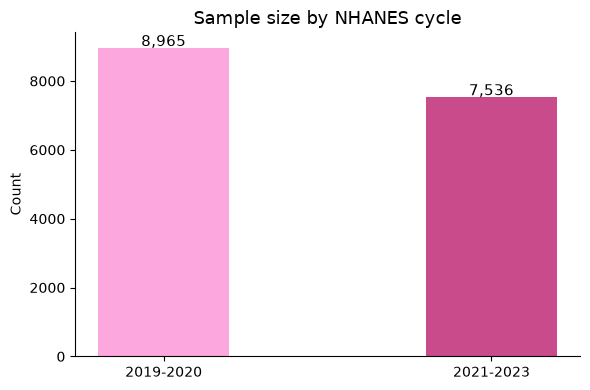

In [4]:
# figure 2: cycle breakdown
fig, ax = plt.subplots(figsize=(6, 4))

cycle_counts = df['cycle_2021'].map({1: '2021-2023', 0: '2019-2020'}).value_counts()
ax.bar(cycle_counts.index, cycle_counts.values, color=PALETTE[:2], width=0.4)
ax.set_title('Sample size by NHANES cycle', fontsize=13)
ax.set_ylabel('Count')
for i, (val, count) in enumerate(cycle_counts.items()):
    ax.text(i, count + 50, f'{count:,}', ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_cycle_breakdown.png', dpi=150)
plt.show()

/var/folders/j9/68ql7jwj6zn7mr_22x6c14zr0000gn/T/ipykernel_14639/2374961492.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(race_rates.index, rotation=30, ha='right')


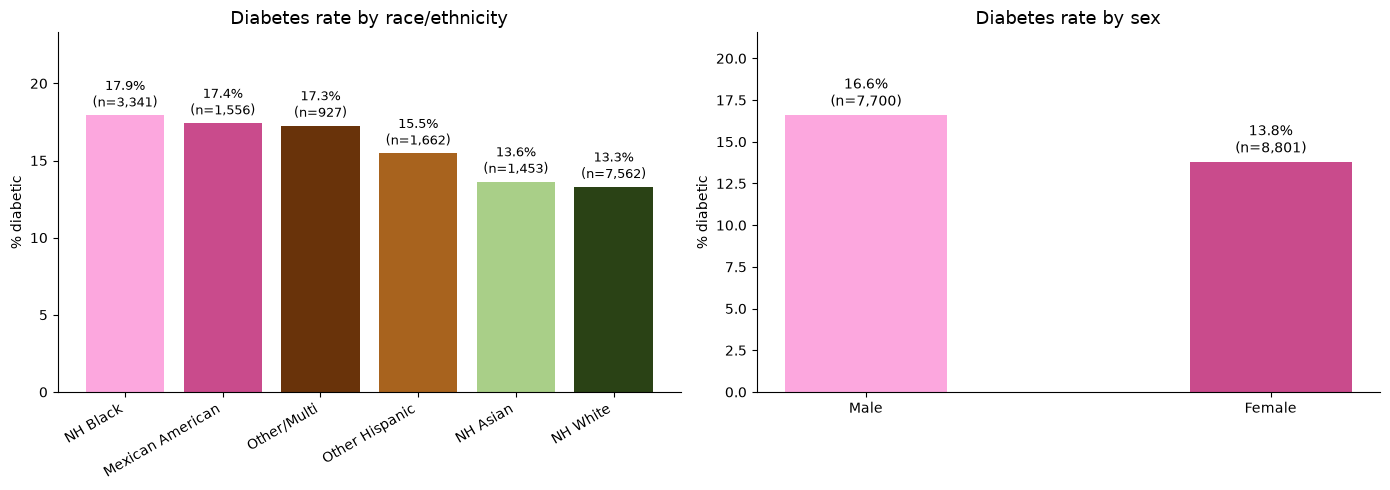

In [44]:
# figure 3: class distribution by subgroup (race and sex)

race_map = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'NH White',
    4: 'NH Black',
    6: 'NH Asian',
    7: 'Other/Multi'
}
sex_map = {1: 'Male', 2: 'Female'}

df['race_label'] = df['RIDRETH3'].map(race_map)
df['sex_label']  = df['RIAGENDR'].map(sex_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_rates = df.groupby('race_label')['diabetes'].mean().sort_values(ascending=False)
race_counts = df.groupby('race_label')['diabetes'].count()

bars = axes[0].bar(race_rates.index, race_rates.values * 100,
                   color=[PALETTE[i % len(PALETTE)] for i in range(len(race_rates))])
axes[0].set_title('Diabetes rate by race/ethnicity', fontsize=13)
axes[0].set_ylabel('% diabetic')
axes[0].set_xticklabels(race_rates.index, rotation=30, ha='right')
axes[0].set_ylim(0, race_rates.max() * 100 * 1.3)
for bar, rate, count in zip(bars, race_rates.values, race_counts[race_rates.index]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1%}\n(n={count:,})', ha='center', va='bottom', fontsize=9)

sex_rates = df.groupby('sex_label')['diabetes'].mean().sort_values(ascending=False)
sex_counts = df.groupby('sex_label')['diabetes'].count()

bars = axes[1].bar(sex_rates.index, sex_rates.values * 100, color=PALETTE[:2], width=0.4)
axes[1].set_title('Diabetes rate by sex', fontsize=13)
axes[1].set_ylabel('% diabetic')
axes[1].set_ylim(0, sex_rates.max() * 100 * 1.3)
for bar, rate, count in zip(bars, sex_rates.values, sex_counts[sex_rates.index]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1%}\n(n={count:,})', ha='center', va='bottom', fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_subgroup_distribution.png', dpi=150)
plt.show()

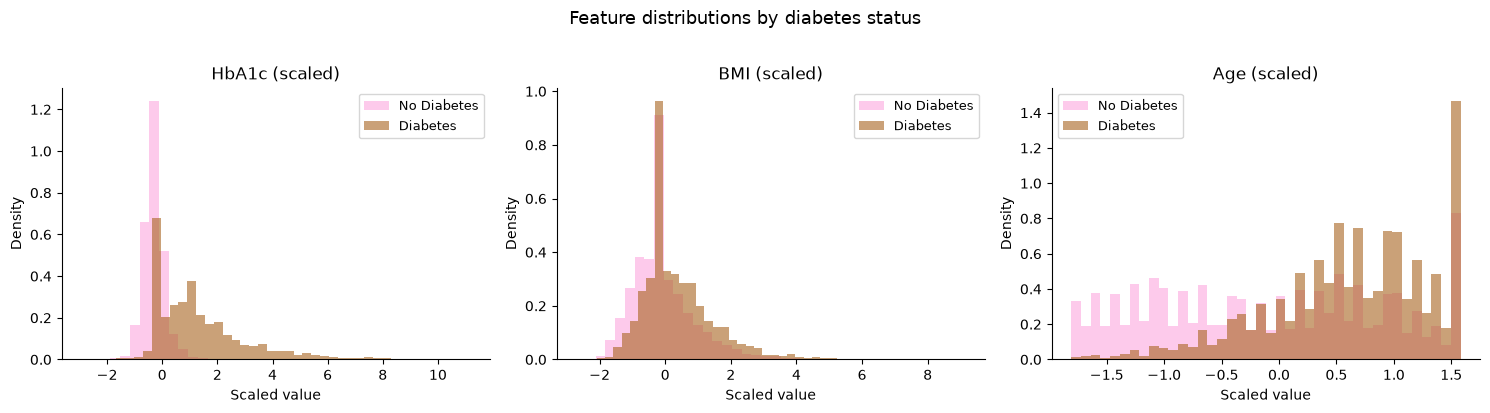

In [45]:
# figure 4: feature distributions by diabetes status

features = ['LBXGH', 'BMXBMI', 'RIDAGEYR']
feature_labels = ['HbA1c (scaled)', 'BMI (scaled)', 'Age (scaled)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, label in zip(axes, features, feature_labels):
    for val, name, color in [(0, 'No Diabetes', PALETTE[0]), (1, 'Diabetes', PALETTE[3])]:
        subset = df[df['diabetes'] == val][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, label=name, color=color, density=True)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Scaled value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Feature distributions by diabetes status', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

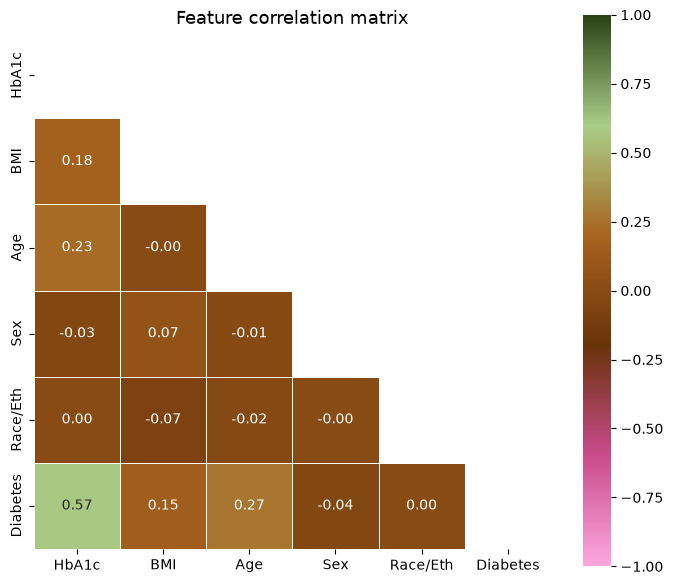

In [46]:
# figure 5: correlation heatmap

numeric_cols = ['LBXGH', 'BMXBMI', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'diabetes']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

corr.index   = ['HbA1c', 'BMI', 'Age', 'Sex', 'Race/Eth', 'Diabetes'][:len(numeric_cols)]
corr.columns = ['HbA1c', 'BMI', 'Age', 'Sex', 'Race/Eth', 'Diabetes'][:len(numeric_cols)]

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=PALETTE_CMAP,
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)

ax.set_title('Feature correlation matrix', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_correlation_heatmap.png', dpi=150)
plt.show()

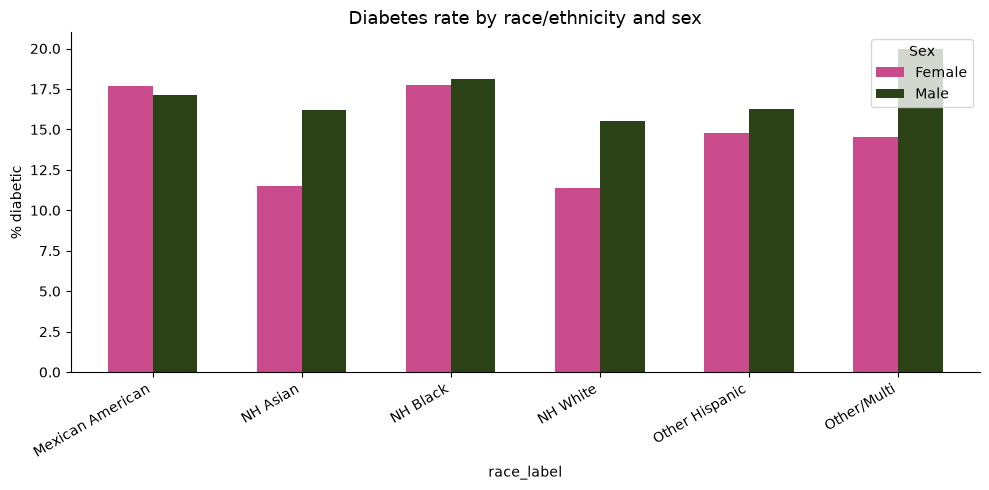

In [55]:
# figure 6: diabetes race by race and sex interaction
pivot = df.groupby(['race_label', 'sex_label'])['diabetes'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, color=[PALETTE[1], PALETTE[5]], width=0.6)

ax.set_title('Diabetes rate by race/ethnicity and sex', fontsize=13)
ax.set_ylabel('% diabetic')
ax.set_xticklabels(pivot.index, rotation=30, ha='right')
ax.legend(title='Sex')
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_race_sex_breakdown.png', dpi=150)
plt.show()

In [56]:
df['stratum'] = df['RIDRETH3'].astype(str) + '_' + df['diabetes'].astype(str)

print("Stratum counts (must all be >= 2 to stratify):")
print(df['stratum'].value_counts().sort_index())

Stratum counts (must all be >= 2 to stratify):
stratum
1.0_0.0    1285
1.0_1.0     271
2.0_0.0    1405
2.0_1.0     257
3.0_0.0    6557
3.0_1.0    1005
4.0_0.0    2742
4.0_1.0     599
6.0_0.0    1255
6.0_1.0     198
7.0_0.0     767
7.0_1.0     160
Name: count, dtype: int64


In [57]:
feature_cols = ['LBXGH', 'BMXBMI', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3']
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df['diabetes']
strata = df['stratum']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2026,        # fix this forever — use 2026 for every model
    stratify=strata         # stratify by race × diabetes
)

print(f"Train: {X_train.shape} — {y_train.mean():.1%} diabetic")
print(f"Test:  {X_test.shape}  — {y_test.mean():.1%} diabetic")

# Verify subgroup representation in both splits
train_df = X_train.copy(); train_df['diabetes'] = y_train
test_df  = X_test.copy();  test_df['diabetes']  = y_test
train_df['race_label'] = train_df['RIDRETH3'].map(race_map)
test_df['race_label']  = test_df['RIDRETH3'].map(race_map)

print("\nDiabetes rate by race — train:")
print(train_df.groupby('race_label')['diabetes'].mean().round(3))
print("\nDiabetes rate by race — test:")
print(test_df.groupby('race_label')['diabetes'].mean().round(3))

Train: (13200, 5) — 15.1% diabetic
Test:  (3301, 5)  — 15.1% diabetic

Diabetes rate by race — train:
race_label
Mexican American    0.174
NH Asian            0.136
NH Black            0.179
NH White            0.133
Other Hispanic      0.155
Other/Multi         0.173
Name: diabetes, dtype: float64

Diabetes rate by race — test:
race_label
Mexican American    0.174
NH Asian            0.137
NH Black            0.179
NH White            0.133
Other Hispanic      0.154
Other/Multi         0.173
Name: diabetes, dtype: float64


In [58]:
# Save all four as CSVs — load these in every future modelling notebook
X_train.to_csv(DATA_OUT / 'X_train.csv', index=False)
X_test.to_csv(DATA_OUT  / 'X_test.csv',  index=False)
y_train.to_csv(DATA_OUT / 'y_train.csv', index=False)
y_test.to_csv(DATA_OUT  / 'y_test.csv',  index=False)

# Also save the full processed df with labels for future reference
df.to_csv(DATA_OUT / 'nhanes_clean_with_labels.csv', index=False)

print("Saved: X_train, X_test, y_train, y_test, nhanes_clean_with_labels")

Saved: X_train, X_test, y_train, y_test, nhanes_clean_with_labels
